In [212]:
import numpy as np
import sympy as sp
from numpy.polynomial.legendre import leggauss
from scipy.linalg import solve
import matplotlib.pyplot as plt


# Prepare font sizes for all the plots
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})
plt.rcParams["axes.formatter.use_mathtext"] = True

In [213]:
#Constants 

omega = 2*np.pi  #Dimensional frequency 

h = 10**(-5) #Half channel height

D = 1.35 * 10**(-10) #Diffusivity coefficient 

L = 5*10**(-3) #Channel lenght 

epsilon = h/L

Omega = (omega * h**2)/D # Dimensionless frequency 

q = np.sqrt(1j * Omega)

q_conj = np.sqrt((-1)* 1j * Omega )

a = np.sqrt(Omega / 2)


In [214]:
# Defining Equations

def P(X, beta):
    return (-1)*(np.sinh(beta * (X - 1)))/(np.sinh(beta))

def P_X(X, beta):
    return (-1)*beta*np.cosh(beta*(X - 1))/(np.sinh(beta))

def P_XX(X, beta):
    return beta*beta*np.sinh(beta - beta*X)/np.sinh(beta)

def P_XXX(X, beta):
    return (-1)*beta*beta*beta*np.cosh(beta - beta*X)/np.sinh(beta)

def U_bar (X, beta, Pe):
    return (-2/3)*P_X(X, beta)

def U_bar_X (X, beta, Pe):
    return (-2/3)*P_XX(X, beta)

def V(X,Y, beta):
    return (-1)*P_XX(X, beta)*((1/3)*Y**3 - Y)

def V_X(X, Y, beta):
    return (-1)*P_XXX(X, beta)*((1/3)*Y**3 - Y)


def K_w(X, beta, Pe):
    return (4/315)*P_XX(X, beta)*P_X(X, beta) - (2/(3*epsilon*Pe))*P_X(X, beta)

def D_w(X, beta, Pe):
    return (8/945)*P_X(X, beta)**2

def A_D(X, beta, Pe):
    return (2/(3*epsilon*Pe))*P_XX(X, beta) - (4/135)*P_XX(X, beta)**2 - (4/135)*P_X(X, beta)*P_XXX(X, beta)


def D_w_X (X, beta):
    return (16/945)*P_X(X, beta)*P_XX(X, beta)

def U_eff(X, beta, Pe):
    return (epsilon**2)*(Pe**2)*(K_w(X, beta, Pe) + D_w_X(X, beta))

def Pe_eff(X, beta, Pe):
    return (U_eff(X, beta, Pe))/(1 + (Pe**2)*(D_w(X, beta)))

def U_ind(X, beta, Pe):
    return (epsilon**2)*(Pe**2)*(( D_w_X(X, beta)))

def U_eff_X(X, beta, Pe):
    return (-1)*A_D(X, beta, Pe)*(epsilon**2)*(Pe**2)

def D_eff (X, beta, Pe):
    return (epsilon**2)*(1 + (Pe**2)*D_w(X, beta, Pe))

def D_eff_X(X, beta, Pe):
    return (16/945)*P_X(X, beta)*P_XX(X, beta)*(Pe**2)*(epsilon**2)


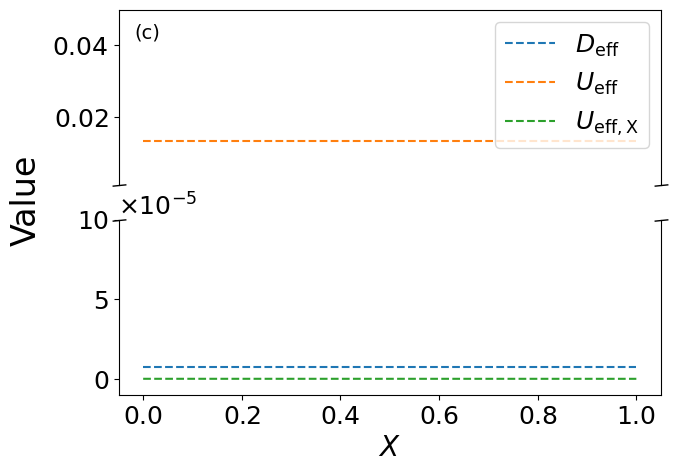

In [215]:
# Plotting Dispersion coefficients for impermeable wall

# Defining parameters
beta = 0.001
Pe = 10

# Prepare the functions
D_values = D_eff(X, beta, Pe)
K_values = U_eff(X, beta, Pe)
A_values = (-1)*U_eff_X(X, beta, Pe)

# Prepare the figure
fig, (ax_upper, ax_lower) = plt.subplots(2, 1, figsize=(7, 5))

#Plot the same functions on both parts of the broken axis

for ax in (ax_upper, ax_lower):
    ax.plot(X, D_values, "--", label=r"$D_\mathrm{eff}$")
    ax.plot(X, K_values, "--", label=r"$U_\mathrm{eff}$")
    ax.plot(X, A_values, "--", label=r"$U_\mathrm{eff,X}$")

#Display only the desired y-ranges

ax_upper.set_ylim(0.001, 0.05)
ax_lower.set_ylim(-0.00001, 0.0001)

#Hide the touching spines

ax_upper.spines["bottom"].set_visible(False)
ax_lower.spines["top"].set_visible(False)

ax_upper.tick_params(
axis="x",
which="both",
bottom=False,
labelbottom=False
)

ax_lower.tick_params(axis="x", which="both", top=False)

#Diagonal break marks

d = 0.10

break_style = dict(marker=[(-1, -d), (1, d)], markersize=10, linestyle="none", color="black", clip_on=False)

ax_upper.plot([0, 1], [0, 0], transform=ax_upper.transAxes, **break_style)

ax_lower.plot([0, 1], [1, 1], transform=ax_lower.transAxes, **break_style)

#Labels and title

#ax_upper.set_title("Dispersion coefficients for impermeable wall", y = 1.07)
ax_lower.set_xlabel(r"$X$")
fig.supylabel("Value", x=-0.03)

#Show the legend only once
ax_upper.legend()

# Add plot numbering
ax_upper.text(0.03, 0.92, "(c)", 
transform=ax_upper.transAxes,
horizontalalignment="left",
verticalalignment="top",
fontsize=14
)

#Display plot
fig.savefig("Steady_Impermeable_wall_coeff.svg", bbox_inches="tight")
plt.show()

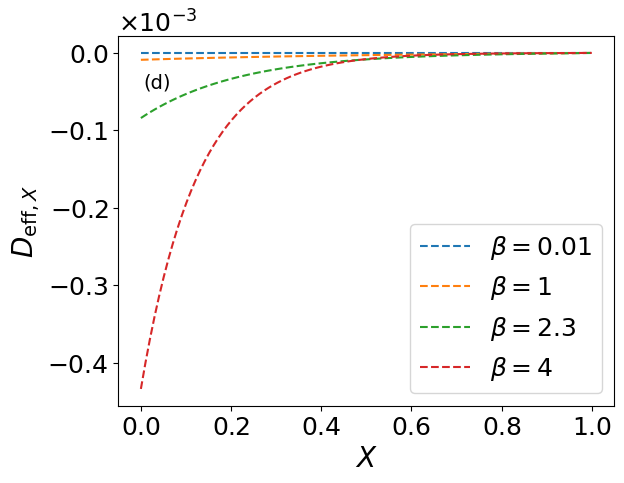

In [217]:
# Plot of $D_{\mathrm{eff},X}$ against $X$

fig, ax = plt.subplots()

ax.plot(X, D_eff_X(X, 0.01, 10), linestyle="--", label=r"$\beta = 0.01$")
ax.plot(X, D_eff_X(X, 1, 10), linestyle="--", label=r"$\beta = 1$")
ax.plot(X, D_eff_X(X, 2.3, 10), linestyle="--", label=r"$\beta = 2.3$")
ax.plot(X, D_eff_X(X, 4, 10), linestyle="--", label=r"$\beta = 4$")

#ax.set_title(r"Plot of $D_{\mathrm{eff},X}$ against $X$")
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$D_{\mathrm{eff},X}$")
ax.legend()

ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, -3)
)

ax.text(0.05, 0.90,"(d)",
    transform=ax.transAxes,
    horizontalalignment="left",
    verticalalignment="top",
    fontsize=14
)

plt.savefig("D_eff_x.svg", bbox_inches="tight")

plt.show()

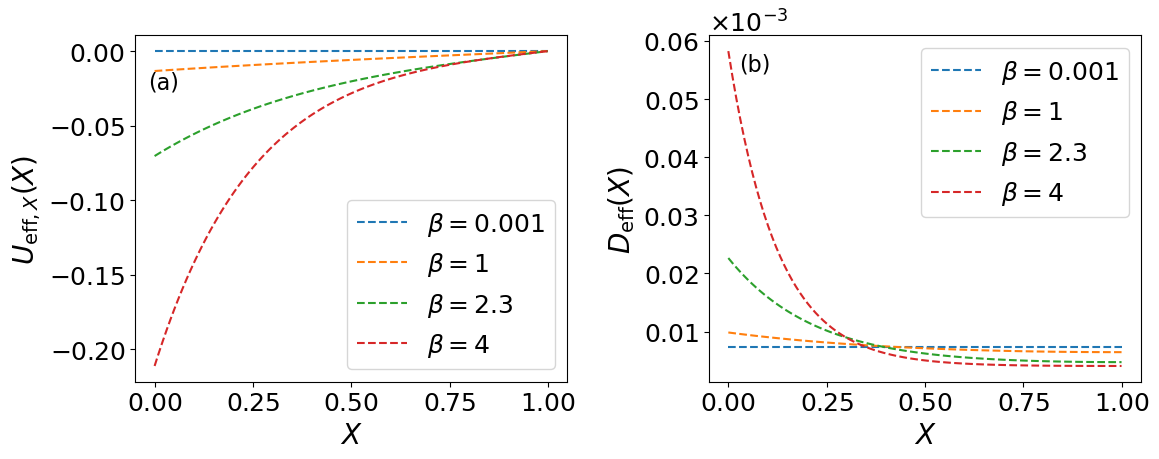

In [219]:
# Plots of U_{eff, X} and D_eff against X for various beta

# Define linespace and parameters 
X = np.linspace(0, 1, 100)

beta_values = [0.001, 1, 2.3, 4]
Pe = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# ------------------------------------------------------------------
# First plot: derivative of effective velocity
# ------------------------------------------------------------------
for beta in beta_values:
    axes[0].plot(X, U_eff_X(X, beta, Pe), linestyle="--", label=fr"$\beta={beta}$")

#axes[0].set_title(r"$U_{\mathrm{eff},X}$ against $X$")
axes[0].set_xlabel(r"$X$")
axes[0].set_ylabel(r"$U_{\mathrm{eff},X}(X)$")
axes[0].legend()

axes[0].text(0.03, 0.90, "(a)",
    transform=axes[0].transAxes,
    horizontalalignment="left",
    verticalalignment="top",
    fontsize=16
)

# ------------------------------------------------------------------
# Second plot: effective diffusivity
# ------------------------------------------------------------------
for beta in beta_values:
    axes[1].plot(X, D_eff(X, beta, Pe), linestyle="--", label=fr"$\beta={beta}$")

#axes[1].set_title(r"$D_{\mathrm{eff}}$ against $X$")
axes[1].set_xlabel(r"$X$")
axes[1].set_ylabel(r"$D_{\mathrm{eff}}(X)$")
axes[1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3),
    useMathText=True
)
axes[1].legend()

axes[1].text(0.07, 0.95, "(b)",
    transform=axes[1].transAxes,
    horizontalalignment="left",
    verticalalignment="top",
    fontsize=16
)

# Display the plot
fig.tight_layout()
fig.savefig(
    f"Fig(c).svg",
    bbox_inches="tight"
)
plt.show()

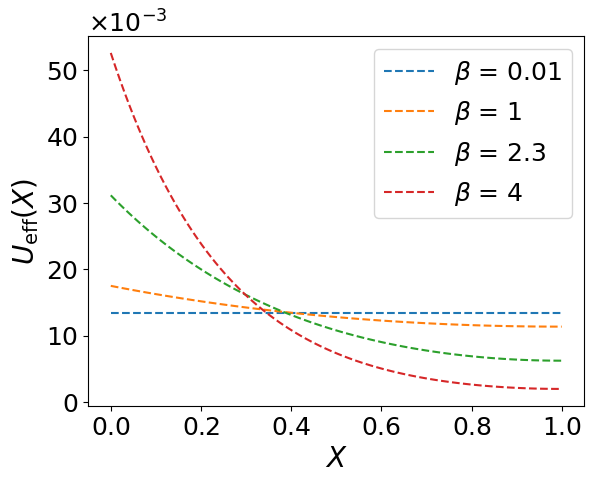

In [220]:
#Plot of $U_{\mathrm{eff}}$ against $X$

plt.plot(X, U_eff(X, 0.01, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, U_eff(X, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, U_eff(X, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, U_eff(X, 4, 10), linestyle = "--", label = r"$\beta$ = 4")
#plt.title(r"Plot of $U_{\mathrm{eff}}$ against $X$")
plt.xlabel(f"$X$")
plt.legend()
plt.ylabel(r"$U_{\mathrm{eff}}(X)$")
plt.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)
plt.savefig(
    f"U_eff_againstX.svg",
    bbox_inches="tight"
)
plt.show()

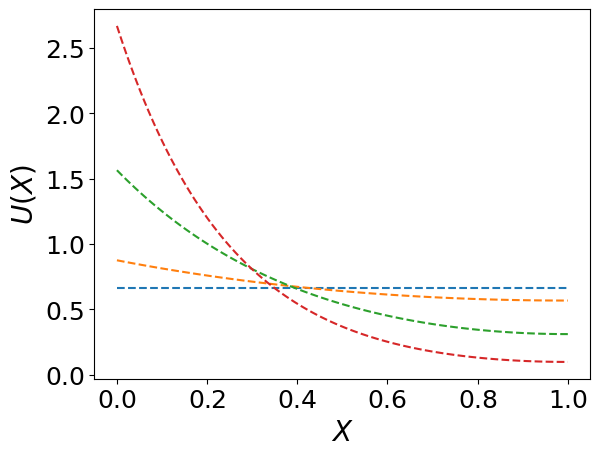

In [222]:
# Plot of $U$ against $X$

plt.plot(X, U_bar(X, 0.01, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, U_bar(X, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, U_bar(X, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, U_bar(X, 4, 10), linestyle = "--", label = r"$\beta$ = 4")
#plt.title(r"Plot of $U$ against $X$")
plt.xlabel(f"$X$")
#plt.legend()
plt.ylabel(f"$U(X)$")
plt.savefig(
    f"U_againstX.svg",
    bbox_inches="tight"
)
plt.show()

In [223]:
# Defining M value and sigma 

def M(X, beta, Pe, sigma):
    return (-1)*((D_eff(X, beta, Pe)/(sigma**2)) + U_eff_X(X, beta, Pe))

def sigma_M(X, beta, Pe):
    return np.sqrt(D_eff(X, beta, Pe)/np.abs(U_eff_X(X, beta, Pe)))

print(sigma_M(0.2, 1.3, 10))
print(M(0.2, 7.5, 10, 0.02))

0.023440666219929015
0.13202015167885078


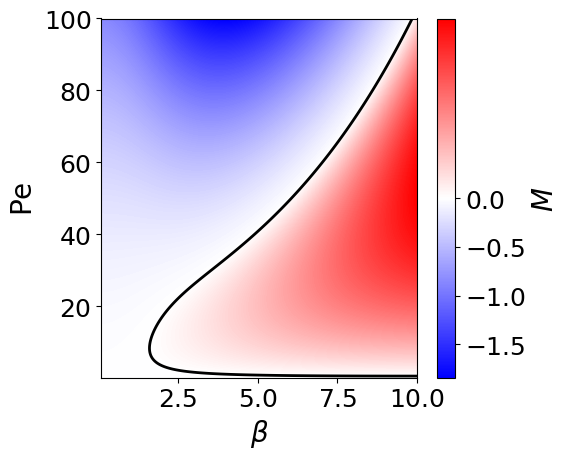

In [226]:
# Plotting M for different inital width and peak position for various beta and Pe

from matplotlib.colors import TwoSlopeNorm

# Define parameters
beta_values = np.linspace(0.1, 10, 400)
Pe_values = np.linspace(0.1, 100.0, 500)

# Create grid
beta_grid, Pe_grid = np.meshgrid(beta_values, Pe_values)

# Define initial width and position of the peak
X_0 = 0.2
sigma_0 = 0.02

# Calculate the M value
M_values = M(X_0, beta_grid, Pe_grid, sigma_0)

# Create figure
plt.figure(figsize=(6, 5))

# Plot M for various beta and Pe
im = plt.imshow(
    M_values,
    extent=[
        beta_values.min(), beta_values.max(),
        Pe_values.min(), Pe_values.max()
    ],
    origin="lower",
    aspect="auto",
    cmap="bwr",
    norm=TwoSlopeNorm(vmin = M_values.min(), vcenter=0, vmax=M_values.max())
)

# Add a contour line where M = 0 
plt.contour(
    beta_values,
    Pe_values,
    M_values,
    levels=[0],
    colors="black",
    linewidths=2
)

# Add colourbar 
cbar = plt.colorbar(im)
cbar.set_label(r"$M$")

plt.xlabel(r"$\beta$")
plt.ylabel(r"$\operatorname{Pe}$")

# plt.title(
#     rf"$M$ as a function of $\beta$ and $\operatorname{{Pe}}$"
#     f"\n$X_0={X_0}$, $\sigma_0={sigma_0}$"
# )

plt.tight_layout()
plt.savefig(
    f"M_S002.svg",
    bbox_inches="tight"
)
plt.show()